In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv(r"C:\Users\SUJAN SURE\OneDrive\Desktop\AIML-3\virtual\Scripts\House_Prediction.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


c:\Users\SUJAN SURE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\SUJAN SURE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Actual vs Predicted city
          Price    Actual city Predicted city
0  5.440000e+05        Seattle        Seattle
1  0.000000e+00         SeaTac        Seattle
2  1.712500e+06        Seattle        Seattle
3  3.650000e+05         Renton        Seattle
4  2.750000e+05    Federal Way        Seattle
5  6.250000e+05      Shoreline        Seattle
6  4.530000e+05       Bellevue        Seattle
7  3.000000e+05           Kent        Seattle
8  4.179857e+05       Kirkland        Seattle
9  6.725000e+05  Mercer Island        Seattle


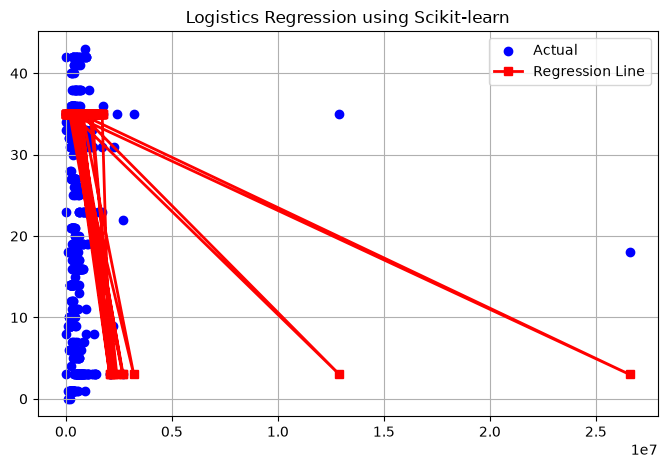

In [6]:
X=df[["price"]]
y=df[["city"]].astype(str) 
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model= LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
#print(model.intercept_)
#print(model.coef_)
y_pred=model.predict(X_test)
result=pd.DataFrame({
    "Price":X_test["price"].values,
    "Actual city":label_encoder.inverse_transform(y_test),
    "Predicted city":label_encoder.inverse_transform(y_pred)
})
print("\n Actual vs Predicted city")
print(result.head(10))

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X_test["price"],
    y_test,
    color="blue",
    label="Actual"
)

plt.plot(
    X_test["price"],
    y_pred,
    color="red",
    marker="s",
    linewidth=2,
    label="Regression Line"
)

plt.title("Logistics Regression using Scikit-learn")
plt.xlabel=("Price")
plt.ylabel=("City")
plt.legend()
plt.grid(True)

plt.show()



c:\Users\SUJAN SURE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



 Actual vs Predicted city
          Price    Actual city Predicted city
0  5.440000e+05        Seattle       Issaquah
1  0.000000e+00         SeaTac         Burien
2  1.712500e+06        Seattle       Bellevue
3  3.650000e+05         Renton        Seattle
4  2.750000e+05    Federal Way       Enumclaw
5  6.250000e+05      Shoreline       Bellevue
6  4.530000e+05       Bellevue       Bellevue
7  3.000000e+05           Kent        Seattle
8  4.179857e+05       Kirkland        Seattle
9  6.725000e+05  Mercer Island       Issaquah


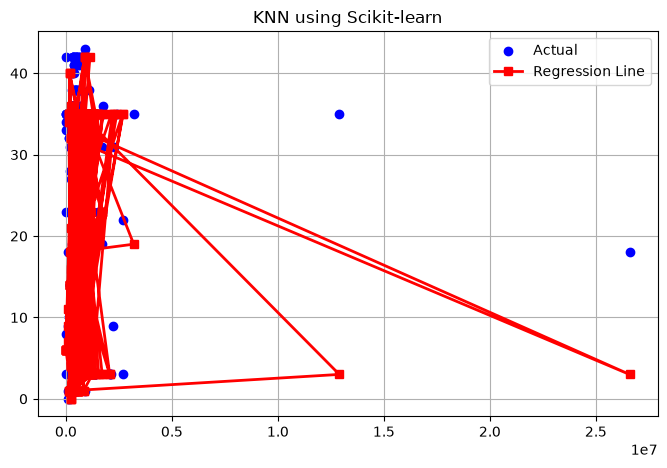

In [7]:
from sklearn.neighbors import KNeighborsClassifier
X=df[["price"]]
y=df[["city"]].astype(str) 
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model= KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
#print(model.intercept_)
#print(model.coef_)
y_pred=model.predict(X_test)
result=pd.DataFrame({
    "Price":X_test["price"].values,
    "Actual city":label_encoder.inverse_transform(y_test),
    "Predicted city":label_encoder.inverse_transform(y_pred)
})
print("\n Actual vs Predicted city")
print(result.head(10))

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X_test["price"],
    y_test,
    color="blue",
    label="Actual"
)

plt.plot(
    X_test["price"],
    y_pred,
    color="red",
    marker="s",
    linewidth=2,
    label="Regression Line"
)

plt.title("KNN using Scikit-learn")
plt.xlabel=("Price")
plt.ylabel=("City")
plt.legend()
plt.grid(True)

plt.show()



Decision Making

c:\Users\SUJAN SURE\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



 Actual vs Predicted city
          Price    Actual city Predicted city
0  5.440000e+05        Seattle       Issaquah
1  0.000000e+00         SeaTac        Seattle
2  1.712500e+06        Seattle       Bellevue
3  3.650000e+05         Renton        Seattle
4  2.750000e+05    Federal Way        Seattle
5  6.250000e+05      Shoreline        Seattle
6  4.530000e+05       Bellevue       Kirkland
7  3.000000e+05           Kent        Seattle
8  4.179857e+05       Kirkland        Seattle
9  6.725000e+05  Mercer Island  Mercer Island


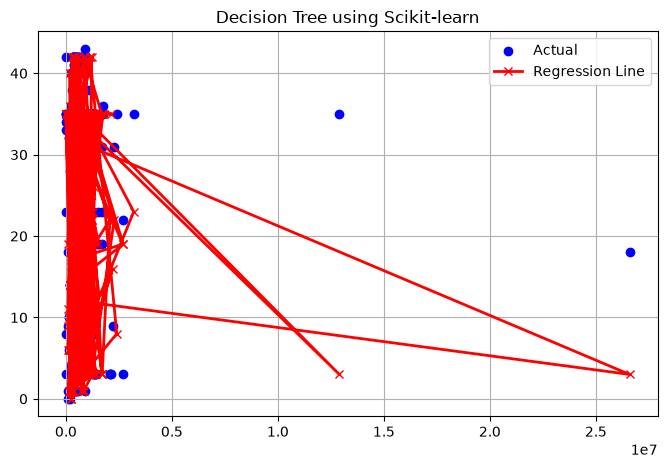

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
X=df[["price"]]
y=df[["city"]].astype(str) 
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model= DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
#print(model.intercept_)
#print(model.coef_)
y_pred=model.predict(X_test)
result=pd.DataFrame({
    "Price":X_test["price"].values,
    "Actual city":label_encoder.inverse_transform(y_test),
    "Predicted city":label_encoder.inverse_transform(y_pred)
})
print("\n Actual vs Predicted city")
print(result.head(10))

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X_test["price"],
    y_test,
    color="blue",
    label="Actual"
)

plt.plot(
    X_test["price"],
    y_pred,
    color="red",
    marker="x",
    linewidth=2,
    label="Regression Line"
)

plt.title("Decision Tree using Scikit-learn")
plt.xlabel=("Price")
plt.ylabel=("City")
plt.legend()
plt.grid(True)

plt.show()


